In [2]:
import pandas as pd
import os
import numpy as np
import pathlib
import glob

import matplotlib.pyplot as plt
import seaborn as sns

Truputis duomenų iš suvestinės užrašų knygelėje

In [198]:
hpc_summary = pd.DataFrame({
    'JOBID': [214457, 214459, 214463, 214465, 214472, 214473, 214477, 214487, 214495, 214503],
    'Cores': np.repeat(12, 10),
    'DataLink': ['87/90', 365, 366, 365, 365, 365, 366, 365, 365, '351/365'],
    'Year': range(2026, 2016, -1),
    'Duration (s)': [484.93, 2002.68, np.nan, np.nan, np.nan, 2099.58, 2099.04, 2087.17, 2780.32, 2219.54]
})

hpc_summary

,JOBID,Cores,DataLink,Year,Duration (s)
0,214457,12,87/90,2026,484.93
1,214459,12,365,2025,2002.68
2,214463,12,366,2024,NaN
3,214465,12,365,2023,NaN
4,214472,12,365,2022,NaN
5,214473,12,365,2021,2099.58
6,214477,12,366,2020,2099.04
7,214487,12,365,2019,2087.17
8,214495,12,365,2018,2780.32
9,214503,12,351/365,2017,2219.54


In [199]:
hpc_summary = hpc_summary.replace(np.nan, hpc_summary['Duration (s)'][1:].mean(skipna=True))

total_seconds = hpc_summary['Duration (s)'].sum()
hours, remainder = divmod(total_seconds, 3600)
minutes = remainder / 60
seconds = int(total_seconds / 60 - minutes)

print(f"Bendra METOP-B duomenų siuntimo trukmė: {hours:.0f} val. {minutes:.0f} min.")

Bendra METOP-B duomenų siuntimo trukmė: 5 val. 40 min.


**PRIMINIMAS: Neleisti viso Note Book!**

### Neapjungtų metų sujungimas

In [ ]:
path = "C:\\Users\\crist\\Downloads\\Processed_files_2021\\"
# path_pattern = r"C:\Users\crist\Downloads\Processed_files_2021\*2021*.csv"

csv_files = os.listdir(path = path)
# csv_files = glob.glob(path_pattern)

print(csv_files[:6]); print(len(csv_files))

In [ ]:
def conect(name, path = path):
    return os.path.join(path, name)

df = pd.concat([
    pd.read_csv(conect(f)) for f in csv_files 
    if os.path.exists(conect(f)) and os.path.getsize(conect(f)) > 1
])

# df = pd.concat([pd.read_csv(f) for f in csv_files
#                 if os.path.getsize(f) > 1], ignore_index=True)

In [63]:
df.head()

,BrO,BrO_Error,H2O,H2O_Error,HCHO,HCHO_Error,NO2,NO2Tropo,NO2Tropo_Error,NO2_Error,O3,O3_Error,SO2,SO2_Error,lat,lon,date
0,3.828157e+13,6.629840e+12,-1.0,-1.0,-1.0,-1.0,8.266425e+14,-1.0,-1.0,8.954492e+13,331.93628,3.111013,-0.476628,0.549171,59.300743,30.291668,2021-01-01
1,4.335799e+13,6.557943e+12,-1.0,-1.0,-1.0,-1.0,7.355490e+14,-1.0,-1.0,8.751005e+13,328.27620,2.985733,0.020478,0.017398,58.966050,30.034346,2021-01-01
2,3.372352e+13,6.441683e+12,-1.0,-1.0,-1.0,-1.0,8.187706e+14,-1.0,-1.0,9.597959e+13,333.31754,2.849227,-1.933218,8.109867,58.632584,29.773224,2021-01-01
3,3.427158e+13,6.443528e+12,-1.0,-1.0,-1.0,-1.0,7.996469e+14,-1.0,-1.0,8.354553e+13,328.38266,3.056865,-0.139363,0.145830,58.295345,29.533236,2021-01-01
4,4.447117e+13,6.805432e+12,-1.0,-1.0,-1.0,-1.0,9.767299e+14,-1.0,-1.0,8.909331e+13,351.67694,3.304269,-0.852744,1.203110,59.163258,24.297420,2021-01-01


In [ ]:
downloads_dir_path = 'C:\\Users\\crist\\Downloads'

df.to_csv(os.path.join(downloads_dir_path, "GOME2B_DATA_2021.csv"), index=False)

---
### Bendras sujungimas

In [6]:
downloads_dir_path = 'C:\\Users\\crist\\Downloads'

csv_files = os.listdir(os.path.join(downloads_dir_path, 'ready GOME2'))
csv_files

['GOME2B_DATA_2017.csv',
 'GOME2B_DATA_2018.csv',
 'GOME2B_DATA_2019.csv',
 'GOME2B_DATA_2020.csv',
 'GOME2B_DATA_2021.csv',
 'GOME2B_DATA_2022.csv',
 'GOME2B_DATA_2023_2024.csv',
 'GOME2B_DATA_2025.csv',
 'GOME2B_DATA_2026.csv']

In [7]:
final_df = pd.concat(pd.read_csv(os.path.join(downloads_dir_path, 'ready GOME2', f)) for f in csv_files)

In [8]:
final_df.shape

(2249938, 17)

In [9]:
final_df = final_df.replace(-1, np.nan)

In [14]:
final_df = final_df.drop(columns=['index'])
final_df.head()

,BrO,BrO_Error,H2O,H2O_Error,HCHO,HCHO_Error,NO2,NO2Tropo,NO2Tropo_Error,NO2_Error,O3,O3_Error,SO2,SO2_Error,lat,lon,date
0,2.576775e+13,1.013240e+13,NaN,NaN,NaN,NaN,2.538129e+15,NaN,NaN,1.904746e+14,292.67026,2.509943,-8.797272,8.637106,59.169120,31.335165,2017-11-25
1,3.932598e+13,9.583962e+12,NaN,NaN,NaN,NaN,2.625460e+15,NaN,NaN,1.585223e+14,292.26376,2.953442,0.883892,3.148954,59.274050,29.968560,2017-11-25
2,3.240653e+13,9.461983e+12,8.740034,31.97990,NaN,NaN,2.137938e+15,NaN,NaN,1.589865e+14,301.23334,2.977952,4.823585,7.494204,59.365433,28.580720,2017-11-25
3,2.675377e+13,9.587332e+12,10.056204,35.03932,NaN,NaN,2.554239e+15,NaN,NaN,1.572743e+14,295.99615,3.166650,-9.691098,15.375847,59.399986,27.305819,2017-11-25
4,3.397294e+13,9.764555e+12,NaN,NaN,NaN,NaN,2.143277e+15,NaN,NaN,1.689406e+14,293.37744,2.601635,-0.884305,94.365890,59.070830,31.547857,2017-11-25


In [15]:
final_df.to_csv('METOPB_full_set.csv', index=False)

---
### Truputis statistikos

In [10]:
final_df = final_df.reset_index()

$$a = \sin^2\left(\frac{\Delta \phi}{2}\right) + \cos \phi_1 \cdot \cos \phi_2 \cdot \sin^2\left(\frac{\Delta \lambda}{2}\right)$$

$$c = 2 \cdot \operatorname{atan2}(\sqrt{a}, \sqrt{1-a})$$

$$d = R \cdot c$$

[Wikipedia: Haversine formula](https://en.wikipedia.org/wiki/Haversine_formula#:~:text=Either%20formula%20is%20only%20an%20approximation%20when,other%20formulas%20in%20the%20geographical%20distance%20article.)

In [16]:
Vilnius = (54.6872, 25.2797)

def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

final_df["km_to_Vilnius"] = haversine_vectorized(
    final_df['lat'], final_df['lon'], 
    Vilnius[0], Vilnius[1]
)

In [17]:
min_dist_df = final_df.groupby('date')['km_to_Vilnius'].min()
print(f"Atstumų didesnių nei 50 km nuo Vilniaus skaičius: {int(min_dist_df[min_dist_df > 50].count())}")

Atstumų didesnių nei 50 km nuo Vilniaus skaičius: 16


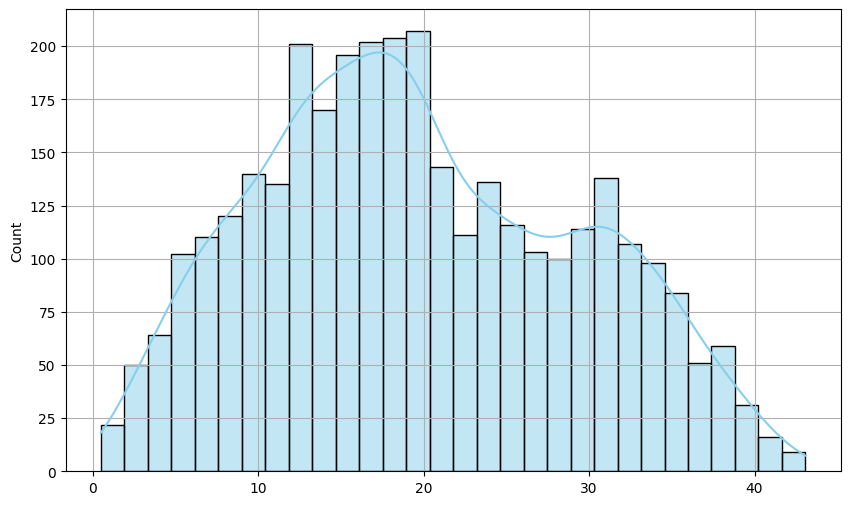

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(min_dist_df.values[min_dist_df.values < 50], kde=True, color='skyblue', bins=30)
plt.grid()
plt.show()

In [19]:
final_df['date'] = pd.to_datetime(final_df['date'])
idx = final_df.groupby(final_df['date'].dt.date)['km_to_Vilnius'].idxmin()
closest_per_day_df = final_df.loc[idx].reset_index()

In [20]:
closest_per_day_df = closest_per_day_df.set_index('date')

In [21]:
closest_per_day_df.head()

,index,BrO,BrO_Error,H2O,H2O_Error,HCHO,HCHO_Error,NO2,NO2Tropo,NO2Tropo_Error,NO2_Error,O3,O3_Error,SO2,SO2_Error,lat,lon,km_to_Vilnius
date,,,,,,,,,,,,,,,,,,
2017-01-01,68939,4.067824e+13,1.023224e+13,NaN,NaN,NaN,NaN,1.264781e+15,NaN,NaN,1.597650e+14,302.81918,1.759856,1.136063,2.270313,54.684470,24.742430,34.535499
2017-01-02,150385,7.065945e+13,1.138130e+13,NaN,NaN,NaN,NaN,7.236719e+14,NaN,NaN,1.764434e+14,379.83438,1.755172,1.360049,2.843774,54.803345,25.401083,15.082633
2017-01-03,233154,4.116689e+13,1.681828e+13,4.462987,27.776356,NaN,NaN,9.663619e+14,NaN,NaN,2.304058e+14,383.20250,1.683177,0.860705,2.764343,54.627434,24.767618,33.602005
2017-01-04,229772,4.442434e+13,1.095781e+13,NaN,NaN,NaN,NaN,1.146257e+15,NaN,NaN,2.067150e+14,388.79135,2.050939,-6.458092,6.844355,54.632540,24.958952,21.506666
2017-01-05,154712,5.585372e+13,9.920312e+12,4.439587,28.882318,NaN,NaN,1.740549e+15,NaN,NaN,1.492338e+14,388.53107,2.883507,-0.614635,3.620795,54.742348,25.373165,8.581625


In [22]:
closest_per_day_df = closest_per_day_df.drop(columns=['level_0', 'index'], errors='ignore')

In [24]:
closest_per_day_df.loc[closest_per_day_df['km_to_Vilnius'] > 50, ['BrO', 'BrO_Error', 'H2O', 
                                                                  'H2O_Error', 'HCHO', 'HCHO_Error',	
                                                                  'NO2', 'NO2Tropo', 'NO2Tropo_Error', 'NO2_Error',
                                                                  'O3', 'O3_Error', 'SO2', 'SO2_Error']] = np.nan

In [27]:
nan_percent = (closest_per_day_df.isna().sum() / len(closest_per_day_df)) * 100
print(nan_percent)

BrO                1.698957
BrO_Error          0.596125
H2O               54.336811
H2O_Error         54.336811
HCHO              67.540984
HCHO_Error        67.540984
NO2                0.476900
NO2Tropo          72.906110
NO2Tropo_Error    72.906110
NO2_Error          0.476900
O3                 0.476900
O3_Error           0.476900
SO2                1.251863
SO2_Error          0.596125
lat                0.000000
lon                0.000000
km_to_Vilnius      0.000000
dtype: float64


Nepanaudosime: H2O, HCHO, NO2Tropo

In [28]:
closest_per_day_df.to_csv('METOP_B_data_Vilnius.csv', index=False)